In [ ]:
#mount google drive to save important data

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os #os to manage files and folders in the system

base_path = "/content/drive/MyDrive/OliveTreeFinalCNNsegmentation"

folders = [ #created folders for diffrent things
    "MaskedImages",
    "PreparedData/train",
    "PreparedData/valid",
    "PreparedData/test",
    "RealYieldCSVs",
    "ModelWeights",
    "TrainingResults",
    "TensorboardLogs"
]

for folder in folders:
    full_path = os.path.join(base_path, folder)
    os.makedirs(full_path, exist_ok=True)
    print(f"✅ Created: {full_path}")


✅ Created: /content/drive/MyDrive/OliveTreeFinalCNNsegmentation/MaskedImages
✅ Created: /content/drive/MyDrive/OliveTreeFinalCNNsegmentation/PreparedData/train
✅ Created: /content/drive/MyDrive/OliveTreeFinalCNNsegmentation/PreparedData/valid
✅ Created: /content/drive/MyDrive/OliveTreeFinalCNNsegmentation/PreparedData/test
✅ Created: /content/drive/MyDrive/OliveTreeFinalCNNsegmentation/RealYieldCSVs
✅ Created: /content/drive/MyDrive/OliveTreeFinalCNNsegmentation/ModelWeights
✅ Created: /content/drive/MyDrive/OliveTreeFinalCNNsegmentation/TrainingResults
✅ Created: /content/drive/MyDrive/OliveTreeFinalCNNsegmentation/TensorboardLogs


In [ ]:
!pip install pycocotools #used for handling COCO-style datasets and masks
import os
import cv2 #OpenCV (cv2) for image processing tasks
import json #read/write annotation files in JSON format
import numpy as np #NumPy for efficient numerical operations and array handling
from tqdm import tqdm # used to display progress bars in loops
from pycocotools.coco import COCO #coco class to work with COCO-style annotation files
from pycocotools import mask as maskUtils #Import the mask module to handle segmentation masks
from PIL import Image #basic image loading, conversion, and saving tasks

In [ ]:
json_path = "/content/drive/MyDrive/OliveTreeFinalCNNsegmentation/DatasetOlive/_annotations.coco.json"
image_dir = "/content/drive/MyDrive/OliveTreeFinalCNNsegmentation/DatasetOlive/data"
output_dir = "/content/drive/MyDrive/OliveTreeFinalCNNsegmentation/MaskedImages"

In [ ]:
# Load COCO annotations
coco = COCO(json_path)
image_ids = coco.getImgIds()

loading annotations into memory...
Done (t=1.03s)
creating index...
index created!


In [ ]:
for img_id in tqdm(image_ids):
    img_info = coco.loadImgs(img_id)[0]
    file_name = img_info['file_name'] #Extract image filename
    image_path = os.path.join(image_dir, file_name)
    image = np.array(Image.open(image_path).convert("RGB"))

    ann_ids = coco.getAnnIds(imgIds=img_id)
    anns = coco.loadAnns(ann_ids) #Load segmentations details for the image

    # Create empty mask
    mask = np.zeros((img_info['height'], img_info['width']), dtype=np.uint8)

    for ann in anns: #Convert segmentation into RLE (Run-Length Encoding) format
        rle = coco.annToRLE(ann)
        m = maskUtils.decode(rle) #Decode the RLE to get a binary mask (1s and 0s)
        mask = np.maximum(mask, m * 255)  # accumulate masks

    # Apply mask to image
    masked_image = cv2.bitwise_and(image, image, mask=mask.astype(np.uint8))

    ##Create the output path and save the masked image (convert RGB to BGR for OpenCV saving)
    out_path = os.path.join(output_dir, file_name)
    cv2.imwrite(out_path, cv2.cvtColor(masked_image, cv2.COLOR_RGB2BGR))

print(f"\n Masked images saved to: {output_dir}")

100%|██████████| 144/144 [02:00<00:00,  1.19it/s]


 Masked images saved to: /content/drive/MyDrive/OliveTreeFinalCNNsegmentation/MaskedImages


In [ ]:
#split the data
import os
import shutil
import random

#Set a fixed random seed to make the data split reproducible
random.seed(42)

# Paths
base_dir = "/content/drive/MyDrive/OliveTreeFinalCNNsegmentation"
masked_dir = os.path.join(base_dir, "MaskedImages")
train_dir = os.path.join(base_dir, "PreparedData/train")
valid_dir = os.path.join(base_dir, "PreparedData/valid")
test_dir  = os.path.join(base_dir, "PreparedData/test")

# List all images
all_images = [f for f in os.listdir(masked_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
random.shuffle(all_images)

# Split ratios
train_ratio = 0.8
valid_ratio = 0.1
test_ratio = 0.1

n_total = len(all_images)
n_train = int(train_ratio * n_total)
n_valid = int(valid_ratio * n_total)

# Split
train_imgs = all_images[:n_train]
valid_imgs = all_images[n_train:n_train + n_valid]
test_imgs  = all_images[n_train + n_valid:]

# Function to copy selected images from the source folder to a destination folder
def copy_images(images, dest_dir):
    for img_name in images:
        src = os.path.join(masked_dir, img_name)
        dst = os.path.join(dest_dir, img_name)
        shutil.copy2(src, dst)
#Copy the images to their respective folders
copy_images(train_imgs, train_dir)
copy_images(valid_imgs, valid_dir)
copy_images(test_imgs,  test_dir)

print(f" Train: {len(train_imgs)}, Valid: {len(valid_imgs)}, Test: {len(test_imgs)}")


 Train: 115, Valid: 14, Test: 15


In [ ]:
from PIL import ImageEnhance, ImageOps
import os
from glob import glob
from PIL import Image
import numpy as np
import random

# augmentation function
def augment_image(image):
    aug_images = []

    # Horizontal Flip
    aug_images.append(ImageOps.mirror(image))

    # Vertical Flip
    aug_images.append(ImageOps.flip(image))

    # Brightness Adjustment
    enhancer = ImageEnhance.Brightness(image)
    aug_images.append(enhancer.enhance(1.2))
    aug_images.append(enhancer.enhance(0.8))

    # Contrast Adjustment
    enhancer = ImageEnhance.Contrast(image)
    aug_images.append(enhancer.enhance(1.2))
    aug_images.append(enhancer.enhance(0.8))

    # Rotation (small angles)
    for angle in [-10, 10, -15, 15]:
        aug_images.append(image.rotate(angle))

    return aug_images

# Run Augmentation
input_dir = "/content/drive/MyDrive/OliveTreeFinalCNNsegmentation/PreparedData/train"
output_dir = input_dir  # Save in the same folder

image_paths = glob(os.path.join(input_dir, "*.jpg"))
 # Loop over each image path
for img_path in image_paths:
    img = Image.open(img_path)
    basename = os.path.basename(img_path).split('.')[0]

    augmented = augment_image(img)

    for i, aug_img in enumerate(augmented):
        save_path = os.path.join(output_dir, f"{basename}_aug{i}.jpg")
        aug_img.save(save_path)


In [ ]:
#extracting yield values from image filenames and saving them into CSV files
import os
import re
import pandas as pd

# Define your base directory (update if needed)
base_path = "/content/drive/MyDrive/OliveTreeFinalCNNsegmentation"

splits = ["train", "valid", "test"]
output_dir = os.path.join(base_path, "RealYieldCSVs")
os.makedirs(output_dir, exist_ok=True)

# Match numbers followed by 'k' or 'kg'
def extract_yield_from_filename(filename):
    match = re.search(r'(\d+)\s*k(?:g)?', filename.lower())
    return float(match.group(1)) if match else None  #  Ensure float here

for split in splits:
    image_dir = os.path.join(base_path, f"PreparedData/{split}")
    data = []

    for filename in os.listdir(image_dir):
        if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
            yield_val = extract_yield_from_filename(filename)
            if yield_val is not None:
                full_path = os.path.join(image_dir, filename)
                data.append({
                    "image_path": full_path,
                    "yield_kg": float(yield_val)  #  Force float again
                })

    df = pd.DataFrame(data)
    df['yield_kg'] = df['yield_kg'].astype('float32')  #  Explicitly set dtype

    output_csv = os.path.join(output_dir, f"{split}_realdata.csv")
    df.to_csv(output_csv, index=False)
    print(f"✅ Saved {split} CSV to: {output_csv} | Total samples: {len(df)}")


✅ Saved train CSV to: /content/drive/MyDrive/OliveTreeFinalCNNsegmentation/RealYieldCSVs/train_realdata.csv | Total samples: 1265
✅ Saved valid CSV to: /content/drive/MyDrive/OliveTreeFinalCNNsegmentation/RealYieldCSVs/valid_realdata.csv | Total samples: 14
✅ Saved test CSV to: /content/drive/MyDrive/OliveTreeFinalCNNsegmentation/RealYieldCSVs/test_realdata.csv | Total samples: 15


In [ ]:

base_csv_dir = "/content/drive/MyDrive/OliveTreeFinalCNNsegmentation/RealYieldCSVs"

# Load each CSV
train_df = pd.read_csv(f"{base_csv_dir}/train_realdata.csv")
valid_df = pd.read_csv(f"{base_csv_dir}/valid_realdata.csv")
test_df  = pd.read_csv(f"{base_csv_dir}/test_realdata.csv")

# Show full file paths for verification
pd.set_option('display.max_colwidth', None)

print("📘 Train Data:")
display(train_df.head(10))

print("\n📗 Validation Data:")
display(valid_df.head(10))

print("\n📕 Test Data:")
display(test_df.head(10))


📘 Train Data:


,image_path,yield_kg
0,/content/drive/MyDrive/OliveTreeFinalCNNsegmentation/PreparedData/train/195-190kg-_jpg.rf.8406d8df9d891c48ef116097d7f9b7c7.jpg,190.0
1,/content/drive/MyDrive/OliveTreeFinalCNNsegmentation/PreparedData/train/319-60kg-_jpg.rf.661e41065152a5c973c1ac9bd1d09582.jpg,60.0
2,/content/drive/MyDrive/OliveTreeFinalCNNsegmentation/PreparedData/train/347-85kg-_jpg.rf.9ebda8dcf4c34caa66842cedbe9d3762.jpg,85.0
3,/content/drive/MyDrive/OliveTreeFinalCNNsegmentation/PreparedData/train/182-225kg-_jpg.rf.fb5af831fd38ceb7f5f87d69f32a5941.jpg,225.0
4,/content/drive/MyDrive/OliveTreeFinalCNNsegmentation/PreparedData/train/346-90kg-_jpg.rf.1dd71195fdcd62cabee2f89a2f34be23.jpg,90.0
5,/content/drive/MyDrive/OliveTreeFinalCNNsegmentation/PreparedData/train/513b-42kg-_jpg.rf.c74e664a52eefd774e28bc0c90b8e4cb.jpg,42.0
6,/content/drive/MyDrive/OliveTreeFinalCNNsegmentation/PreparedData/train/14b-140kg-_jpg.rf.a98017f185afef38f652ec21b280aa82.jpg,140.0
7,/content/drive/MyDrive/OliveTreeFinalCNNsegmentation/PreparedData/train/400-60kg-_jpg.rf.9c429db06e8ad8dd61aade5a6b270124.jpg,60.0
8,/content/drive/MyDrive/OliveTreeFinalCNNsegmentation/PreparedData/train/418-60kg-_jpg.rf.34869ead09d0ae2b3bb537d14086267a.jpg,60.0
9,/content/drive/MyDrive/OliveTreeFinalCNNsegmentation/PreparedData/train/352-30kg-_jpg.rf.46cf7b8ab9e2442e8683e6ea6354a5d8.jpg,30.0



📗 Validation Data:


,image_path,yield_kg
0,/content/drive/MyDrive/OliveTreeFinalCNNsegmentation/PreparedData/valid/229-50kg-_jpg.rf.0098c2d91f2264df0e2abe62d064caf8.jpg,50.0
1,/content/drive/MyDrive/OliveTreeFinalCNNsegmentation/PreparedData/valid/12a-84kg-_jpg.rf.62ea1e2fbb6b16f63243ed7d00adca6c.jpg,84.0
2,/content/drive/MyDrive/OliveTreeFinalCNNsegmentation/PreparedData/valid/409-50kg-_jpg.rf.9da802c2ca1da74e32bfc728179eb4ce.jpg,50.0
3,/content/drive/MyDrive/OliveTreeFinalCNNsegmentation/PreparedData/valid/169-70kg-_jpg.rf.507ab52361282ca7a147ee6c2818e4a8.jpg,70.0
4,/content/drive/MyDrive/OliveTreeFinalCNNsegmentation/PreparedData/valid/176-50kg-_jpg.rf.6f2e464645ffb0543664217e827684a8.jpg,50.0
5,/content/drive/MyDrive/OliveTreeFinalCNNsegmentation/PreparedData/valid/355-68kg-_jpg.rf.15ef00967b2e9a97dca2fe3bfd994c83.jpg,68.0
6,/content/drive/MyDrive/OliveTreeFinalCNNsegmentation/PreparedData/valid/236-50kg-_jpg.rf.0872e7c4f71f0c664fa66c71a970a52c.jpg,50.0
7,/content/drive/MyDrive/OliveTreeFinalCNNsegmentation/PreparedData/valid/482b-75kg-_jpg.rf.4d14f4f4d6d712545029ec862b63af21.jpg,75.0
8,/content/drive/MyDrive/OliveTreeFinalCNNsegmentation/PreparedData/valid/178-90kg-_jpg.rf.2f2789b0f89638d84226e0b295425a34.jpg,90.0
9,/content/drive/MyDrive/OliveTreeFinalCNNsegmentation/PreparedData/valid/132-74k-_jpg.rf.e4b31b17585171bacdce3908aeb542f2.jpg,74.0



📕 Test Data:


,image_path,yield_kg
0,/content/drive/MyDrive/OliveTreeFinalCNNsegmentation/PreparedData/test/95-78kg-_jpg.rf.bc8cd491e090fc755da0af9bafa50e52.jpg,78.0
1,/content/drive/MyDrive/OliveTreeFinalCNNsegmentation/PreparedData/test/282-60kg-_jpg.rf.929c93511cf57917dd95c97f7eb881f5.jpg,60.0
2,/content/drive/MyDrive/OliveTreeFinalCNNsegmentation/PreparedData/test/171-65kg-_jpg.rf.996f4ed965f0758bf46e7b8d56ebe475.jpg,65.0
3,/content/drive/MyDrive/OliveTreeFinalCNNsegmentation/PreparedData/test/137-105kg-_jpg.rf.6b867c3a15888388e2a0188b7d9e7ece.jpg,105.0
4,/content/drive/MyDrive/OliveTreeFinalCNNsegmentation/PreparedData/test/126-60kg-_jpg.rf.dde1ff67df05e7915bc106e1f48f5e9e.jpg,60.0
5,/content/drive/MyDrive/OliveTreeFinalCNNsegmentation/PreparedData/test/450b-50kg-_jpg.rf.a730147c1e2f2c13ee112184ef56495c.jpg,50.0
6,/content/drive/MyDrive/OliveTreeFinalCNNsegmentation/PreparedData/test/57-70k-_jpg.rf.6799933996eca27ae82be4ada2f7341c.jpg,70.0
7,/content/drive/MyDrive/OliveTreeFinalCNNsegmentation/PreparedData/test/1a-63kg-_jpg.rf.0e6159e6966ac198a943b3b07a4a0561.jpg,63.0
8,/content/drive/MyDrive/OliveTreeFinalCNNsegmentation/PreparedData/test/167-90kg-_jpg.rf.43e29239b022ee8c9d0b4974354db0dc.jpg,90.0
9,/content/drive/MyDrive/OliveTreeFinalCNNsegmentation/PreparedData/test/129-50kg-_jpg.rf.f120281c4347a47682903b08d297212a.jpg,50.0


In [ ]:
base_path="/content/drive/MyDrive/OliveTreeFinalCNNsegmentation"
csv_dir="/content/drive/MyDrive/OliveTreeFinalCNNsegmentation/RealYieldCSVs"

In [ ]:
import os
import pandas as pd
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

csv_dir = os.path.join(base_path, "RealYieldCSVs")
train_csv = os.path.join(csv_dir, "train_realdata.csv")
valid_csv = os.path.join(csv_dir, "valid_realdata.csv")
test_csv = os.path.join(csv_dir, "test_realdata.csv")

# Preprocessing pipline (Resize, Normalize)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


In [ ]:
# Dataset Class
class OliveYieldDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.data = pd.read_csv(csv_file)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = self.data.iloc[idx]['image_path']
        yield_val = self.data.iloc[idx]['yield_kg']
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(yield_val, dtype=torch.float32)

In [ ]:
#Instantiate datasets
train_dataset = OliveYieldDataset(train_csv, transform=transform)
valid_dataset = OliveYieldDataset(valid_csv, transform=transform)
test_dataset  = OliveYieldDataset(test_csv, transform=transform)

In [ ]:
# DataLoaders +batch size of 16 images with shuffling
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=16)
test_loader  = DataLoader(test_dataset, batch_size=16)

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
import os
from torch.utils.tensorboard import SummaryWriter

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load and modify ResNet18 for regression
model = models.resnet18(pretrained=True)

# Unfreeze all layers
for param in model.parameters():
    param.requires_grad = True

# Replace final layer with a regression head
model.fc = nn.Linear(model.fc.in_features, 1)
model = model.to(device)

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=5e-5)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 184MB/s]


In [ ]:

def train_model(model, train_loader, valid_loader, criterion, optimizer,
                epochs=100,
                weights_dir="/content/drive/MyDrive/OliveTreeFinalCNNsegmentation/ModelWeights",
                log_dir="/content/drive/MyDrive/OliveTreeFinalCNNsegmentation/TensorboardLogs"):

    os.makedirs(weights_dir, exist_ok=True)
    writer = SummaryWriter(log_dir)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=3)

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for imgs, labels in train_loader:
            imgs = imgs.to(device)
            labels = labels.to(device).float()  #  Ensure float
            optimizer.zero_grad()
            outputs = model(imgs).view(-1)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Validation phase
        model.eval()
        val_loss = 0.0
        y_true, y_pred = [], []

        with torch.no_grad():
            for imgs, labels in valid_loader:
                imgs = imgs.to(device)
                labels = labels.to(device).float()  # ✅ Ensure float
                outputs = model(imgs).view(-1)      # ✅ Fix shape
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                y_true.extend(labels.cpu().numpy())
                y_pred.extend(outputs.cpu().numpy())

        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(valid_loader)
        mse = mean_squared_error(y_true, y_pred)
        rmse = mse ** 0.5
        mae = mean_absolute_error(y_true, y_pred)

        print(f"📘 Epoch {epoch+1}: Train Loss = {avg_train_loss:.2f} | Val Loss = {avg_val_loss:.2f} | RMSE = {rmse:.2f} | MAE = {mae:.2f}")
        writer.add_scalars("Loss", {"Train": avg_train_loss, "Validation": avg_val_loss}, epoch+1)
        writer.add_scalars("Metrics", {"Val_RMSE": rmse, "Val_MAE": mae}, epoch+1)

        # Save model weights after every epoch
        torch.save(model.state_dict(), os.path.join(weights_dir, f"resnet18_epoch{epoch+1}.pt"))

    writer.close()


In [ ]:
#training
train_model(model, train_loader, valid_loader, criterion, optimizer, epochs=80)


📘 Epoch 1: Train Loss = 5395.97 | Val Loss = 3577.58 | RMSE = 59.81 | MAE = 58.25
📘 Epoch 2: Train Loss = 5063.90 | Val Loss = 3750.49 | RMSE = 61.24 | MAE = 59.62
📘 Epoch 3: Train Loss = 4678.94 | Val Loss = 2757.14 | RMSE = 52.51 | MAE = 50.63
📘 Epoch 4: Train Loss = 4388.64 | Val Loss = 3173.71 | RMSE = 56.34 | MAE = 54.88
📘 Epoch 5: Train Loss = 4138.82 | Val Loss = 3055.40 | RMSE = 55.28 | MAE = 53.92
📘 Epoch 6: Train Loss = 3813.08 | Val Loss = 3236.30 | RMSE = 56.89 | MAE = 55.63
📘 Epoch 7: Train Loss = 3512.27 | Val Loss = 2153.66 | RMSE = 46.41 | MAE = 44.40
📘 Epoch 8: Train Loss = 3188.63 | Val Loss = 1609.65 | RMSE = 40.12 | MAE = 37.64
📘 Epoch 9: Train Loss = 2974.71 | Val Loss = 2433.12 | RMSE = 49.33 | MAE = 47.52
📘 Epoch 10: Train Loss = 2696.42 | Val Loss = 2338.74 | RMSE = 48.36 | MAE = 47.03
📘 Epoch 11: Train Loss = 2410.85 | Val Loss = 1035.00 | RMSE = 32.17 | MAE = 28.84
📘 Epoch 12: Train Loss = 2203.71 | Val Loss = 1536.49 | RMSE = 39.20 | MAE = 37.13
📘 Epoch 13: T

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 1)
model.load_state_dict(torch.load('/content/drive/MyDrive/OliveTreeFinalCNNsegmentation/ModelWeights/resnet18_epoch32.pt'))
model.to(device)
model.eval()

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
def predict(model, loader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            outputs = model(imgs).squeeze().cpu()
            y_true.extend(labels.numpy())
            y_pred.extend(outputs.numpy())
    return y_pred, y_true


In [ ]:
y_pred, y_true = predict(model, test_loader)

In [ ]:
#evaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_predictions(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = mse ** 0.5
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

#print metrics
    print(f"📊 RMSE: {rmse:.2f}")
    print(f"📊 MAE : {mae:.2f}")
    print(f"📊 R²  : {r2:.2f}")

evaluate_predictions(y_true, y_pred)


📊 RMSE: 19.15
📊 MAE : 15.53
📊 R²  : -0.14


In [ ]:
import matplotlib.pyplot as plt


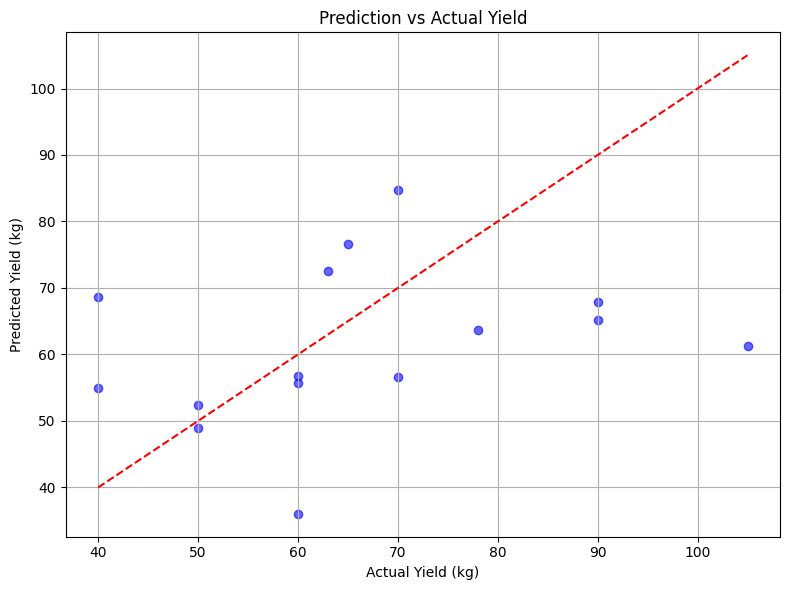

In [ ]:
def plot_predictions(y_true, y_pred, save_path):
    plt.figure(figsize=(8,6))
    plt.scatter(y_true, y_pred, c='blue', alpha=0.6)
    plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--')
    plt.xlabel("Actual Yield (kg)")
    plt.ylabel("Predicted Yield (kg)")
    plt.title("Prediction vs Actual Yield")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()

plot_predictions(y_true, y_pred, "/content/drive/MyDrive/OliveTreeFinalCNNsegmentation/TrainingResults/test_predictions_plot.png")


In [ ]:
df = pd.DataFrame({
    "Real_Yield_kg": y_true,
    "Predicted_Yield_kg": [round(p, 2) for p in y_pred]
})
df.to_csv("/content/drive/MyDrive/OliveTreeFinalCNNsegmentation/TrainingResults/test_real_vs_predicted.csv", index=False)
print("✅ CSV saved.")


✅ CSV saved.


In [ ]:
from IPython.display import display

# Display the first 10 rows of the real vs predicted DataFrame
print(" Real vs Predicted Yield (kg):")
display(df.head(15))


 Real vs Predicted Yield (kg):


,Real_Yield_kg,Predicted_Yield_kg
0,78.0,63.660000
1,60.0,55.650002
2,65.0,76.580002
3,105.0,61.330002
4,60.0,36.040001
5,50.0,48.970001
6,70.0,84.779999
7,63.0,72.599998
8,90.0,65.250000
9,50.0,52.459999
